In [1]:
# Basic data science
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Load specific forecasting tools
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tools.eval_measures import rmse

# Ignore harmless warnings
import warnings
warnings.filterwarnings("ignore")

# Database & data manipulation
import duckdb
from sqlalchemy import (
    create_engine
)
import os
from dotenv import load_dotenv
from pipeline.dbloader import DBLoader

# Import path to read .sql files
from pathlib import Path

In [2]:
conn = duckdb.connect()

# DuckDB connection to PostgreSQL
conn.execute("INSTALL postgres")
conn.execute("LOAD postgres")

# Attach to PostgreSQL database directly
conn.execute(f"""
    ATTACH '
            host={os.getenv("POSTGRES_HOST")} 
            port={os.getenv("POSTGRES_PORT", 5432)} 
            dbname={os.getenv("POSTGRES_DB")}
            user={os.getenv("POSTGRES_USER")}
            password={os.getenv("POSTGRES_PASSWORD")}
            '
    AS pg (TYPE postgres)
""")

## Analysis

In [3]:
drill_set_rel = conn.sql("SELECT * FROM pg.silver.v_ml_drilling_set")

In [4]:
drill_set_rel.describe()

┌─────────┬────────────┬───────────────────┬────────────────────┬─────────┬───────────────────┬───────────────────┬─────────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬─────────────────────┬───────────────────┬───────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬─────────────────────┬─────────────────────┬────────────────────┬───────────────────┬────────────────────┬────────────────────┬───────────────────┬────────────────────┬───────────────────┬────────────────────┬────────────────────┬────────────────────┬───────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬─────────────────────┬─────────────────────┬───────────────────┬────────────────────┬───────────────────┬────────────────────┬─────────────────────┬────────────────────┬────────────────────┬─────────────────────┬────────────────────┬───

<Axes: title={'center': 'Check for missing data'}>

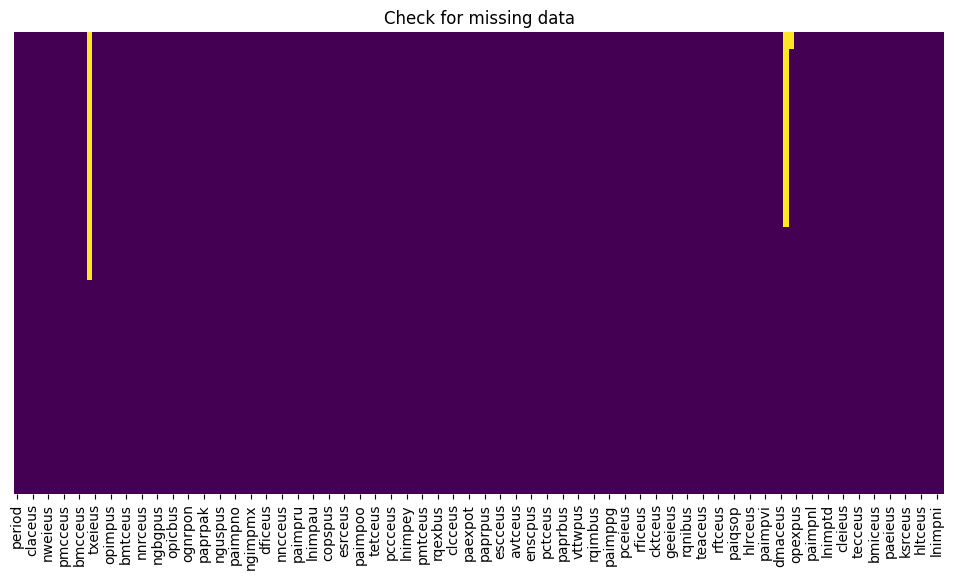

In [5]:
# Check for missing data

fig = plt.figure(figsize=(12,6)) # Setting `plt` obj global size to (12 x 6)
ax = plt.axes()
ax.set_title("Check for missing data")
sns.heatmap(
    drill_set_rel.df().isnull(),
    yticklabels=False,
    cbar=False,
    cmap='viridis',
    ax=ax
    )

In [6]:
test_df = drill_set_rel.df()
test_df['period'] = pd.to_datetime(test_df['period'])
test_df = test_df.set_index('period')
test_df = test_df.sort_index()

In [7]:
# testing
print("Type: ", type(test_df.index))
print(f"""Date Range:
Minimum: {test_df.index.min()}
Maximum: {test_df.index.max()}
""")

Type:  <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Date Range:
Minimum: 2000-01-01 00:00:00
Maximum: 2025-12-01 00:00:00



## Oil Variables Feature Engineering

* Get count of remedial rigs aka rigs that are not for oil or gas.
* Merge monthly data columns with weekly data columns to increase data density
* Re-scale Oil Storage, merge data from Oil Storage features
* Interporlate features
* Drop extra features   

### Feature Group: Rig Count

In [8]:
monthly_avg_rel = conn.sql(f"""
    SELECT
        period
        ,COALESCE(PANRPUS, 0)   AS oilrig_count
        ,COALESCE(NGNRPUS, 0)   AS gasrig_count
        ,COALESCE(OGNRPON, 0)   AS onshorerig_count
        ,COALESCE(OGNRPOF, 0)   AS offshorerig_count
        ,COALESCE(OGNRPUS, 0)   AS totalrig_count
    FROM drill_set_rel
""")

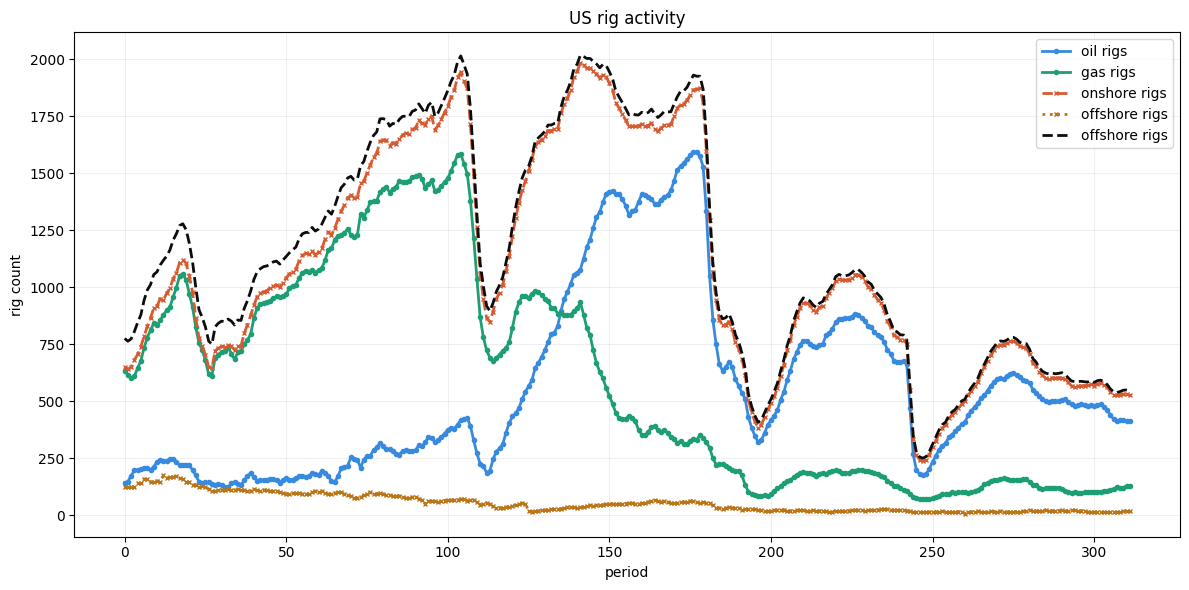

In [9]:
monthly_avg_df = monthly_avg_rel.df()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(monthly_avg_df.index, monthly_avg_df['oilrig_count'],
        color='#378ADD', marker='o', markersize=3,
        linewidth=2, label='oil rigs')

ax.plot(monthly_avg_df.index, monthly_avg_df['gasrig_count'],
        color='#1D9E75', marker='o', markersize=3,
        linewidth=2, label='gas rigs')

ax.plot(monthly_avg_df.index, monthly_avg_df['onshorerig_count'],
        color='#D85A30', marker='x', markersize=3,
        linewidth=2, linestyle='--', label='onshore rigs')

ax.plot(monthly_avg_df.index, monthly_avg_df['offshorerig_count'],
        color='#BA7517', marker='x', markersize=3,
        linewidth=2, linestyle=':', label='offshore rigs')

ax.plot(monthly_avg_df.index, monthly_avg_df['totalrig_count'],
        color="#0C0C0C", markersize=3,
        linewidth=2, linestyle='--', label='offshore rigs')


ax.set_title('US rig activity')
ax.set_xlabel('period')
ax.set_ylabel('rig count')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [10]:
monthly_avg_rel_rem = conn.sql(f"""
    SELECT
        period
        ,oilrig_count
        ,gasrig_count
        ,onshorerig_count
        ,offshorerig_count
        ,totalrig_count - (oilrig_count + gasrig_count)     AS remrig_count 
        ,totalrig_count
    FROM monthly_avg_rel
""")
monthly_avg_rel_rem

┌────────────┬──────────────┬──────────────┬──────────────────┬───────────────────┬──────────────┬────────────────┐
│   period   │ oilrig_count │ gasrig_count │ onshorerig_count │ offshorerig_count │ remrig_count │ totalrig_count │
│    date    │    double    │    double    │      double      │      double       │    double    │     double     │
├────────────┼──────────────┼──────────────┼──────────────────┼───────────────────┼──────────────┼────────────────┤
│ 2000-01-01 │        143.0 │        632.0 │            650.0 │             125.0 │          0.0 │          775.0 │
│ 2000-02-01 │        147.0 │        616.0 │            641.0 │             122.0 │          0.0 │          763.0 │
│ 2000-03-01 │        173.0 │        600.0 │            649.0 │             124.0 │          0.0 │          773.0 │
│ 2000-04-01 │        196.0 │        609.0 │            680.0 │             125.0 │          0.0 │          805.0 │
│ 2000-05-01 │        199.0 │        645.0 │            705.0 │         

### Feature Group: Imports and Exports

In [11]:
# # Find all the 'Petroleum Imports' series
total_import_cols = ", ".join(list(conn.sql("""
    SELECT 
        msn
    FROM pg.silver.v_total_energy_series
    WHERE series_description LIKE '%Petroleum Imports%'
        AND series_description LIKE '%Thousand Barrels%'
    	AND series_description NOT LIKE '%Total%'
""").df()['msn']))
print(total_import_cols)

PAIMPMX, PAIMPVI, PAIMPIQ, PAIMPLY, PAIMPBZ, PAIMPOT, PAIMPNO, PAIMPUK, PAIMPKU, PAIMPAG, PAIMPUA, PAIMPCN, PAIMPPG, PAIMPNI, PAIMPNL, PAIMPOO, PAIMPEN, PAIMPCL, PAIMPVE, PAIMPRU, PAIMPSA


In [12]:
# # Find all the 'Petroleum Exports' series
total_export_cols = ", ".join(list(conn.sql("""
    SELECT 
        msn
    FROM pg.silver.v_total_energy_series
    WHERE series_description LIKE '%Petroleum Exports%'
        AND series_description LIKE '%Thousand Barrels%'
    	AND series_description NOT LIKE '%Total%'
""").df()['msn']))
print(total_export_cols)

PAEXPJA, PAEXPNL, PAEXPOT, PAEXPMX, PAEXPSK, PAEXPUK, PAEXPCN, PAEXPBZ, PAEXPIH, PAEXPSN, PAEXPCH


In [13]:
import_export = conn.sql(f"""
    SELECT
        {total_import_cols}
        ,{total_export_cols}
    FROM drill_set_rel
""")

In [14]:
import_export.df().columns

Index(['paimpmx', 'paimpvi', 'paimpiq', 'paimply', 'paimpbz', 'paimpot',
       'paimpno', 'paimpuk', 'paimpku', 'paimpag', 'paimpua', 'paimpcn',
       'paimppg', 'paimpni', 'paimpnl', 'paimpoo', 'paimpen', 'paimpcl',
       'paimpve', 'paimpru', 'paimpsa', 'paexpja', 'paexpnl', 'paexpot',
       'paexpmx', 'paexpsk', 'paexpuk', 'paexpcn', 'paexpbz', 'paexpih',
       'paexpsn', 'paexpch'],
      dtype='object')

In [15]:
def split_and_trim_str(cols: str) -> list:
    return [x.strip() for x in cols.split(",")]

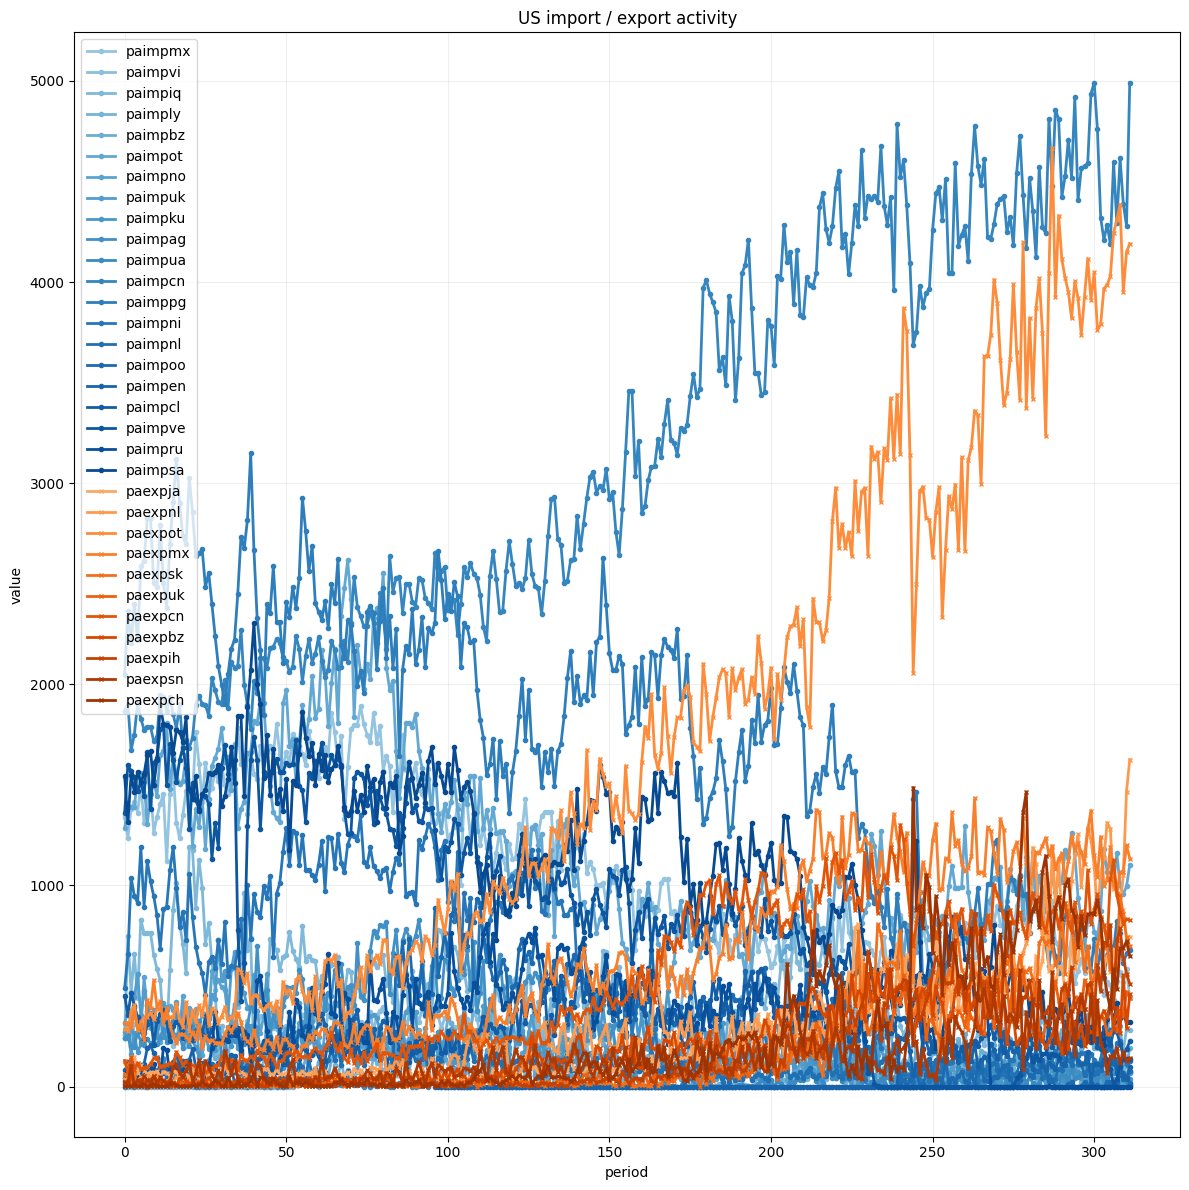

In [16]:
import_cols = [c.lower() for c in split_and_trim_str(total_import_cols)]
export_cols = [c.lower() for c in split_and_trim_str(total_export_cols)]

# Generate distinct colors for each series
import_colors = cm.Blues(np.linspace(0.4, 0.9, len(import_cols)))
export_colors = cm.Oranges(np.linspace(0.4, 0.9, len(export_cols)))

import_export_df = import_export.df()

fig, ax = plt.subplots(figsize=(12, 12))

for col, color in zip(import_cols, import_colors):
    ax.plot(import_export_df.index, import_export_df[col],
            color=color, marker='o', markersize=3,
            linewidth=2, label=col)

for col, color in zip(export_cols, export_colors):
    ax.plot(import_export_df.index, import_export_df[col],
            color=color, marker='x', markersize=3,
            linewidth=2, label=col)

ax.set_title('US import / export activity')
ax.set_xlabel('period')
ax.set_ylabel('value')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Selecting Features

In [17]:
# Features from antoniodagnino

# --- Oil Features ---
# - Oil price:                              oil_price.sql
# - Oil rig count:                          oil_rigs.sql
# - Gas rig count:                          gas_rigs.sql
# - Oil well count:                         oil_wells.sql
# - Oil storage:                            v_total_energy_crude_inv         
# - Oil days of supply                      *NOT FOUND*        
# - US Population                           t_us_population    
# - US Emissions                            us_emissions.sql
# - REM Rig Count                           *built into the query
# - Oil Imports                             oil_imports.sql    
# - Oil Exports                             oil_exports.sql
# - Oil consumption                         oil_consumption.sql              
# - Oil Production                          oil_production.sql

# --- Gas Features ---
# - Gas Price                               gas_price.sql            
# - Gas rig count                           gas_rigs.sql
# - Onshore Count                           onshore_rigs.sql
# - Offshore count                          offshore_rigs.sql
# - Gas well Count                          gas_wells.sql
# - Gas Imports                             gas_imports.sql               
# - Gas Exports                             gas_exports.sql
# - Gas production amount                   gas_production.sql
# - Gas consumption amount                  gas_consumption.sql
# - Gas storage amount                      gas_torage.sql

In [18]:
def build_training_set(
        sql_dir: str = "../src/feature_engineering_sql_scripts",
        specific_features: str = None
):
    ml_set_cols = []
    
    # Grabs the shared files in the main directory
    for sql_file in sorted(Path(sql_dir).glob("*.sql")):
        print(f"Running {sql_file.name}...")
        query = sql_file.read_text()
        conn.execute(query)

        
        res = conn.execute(query).fetchall()  # list of tuples
        ml_set_cols.extend([row[0].lower() for row in res])
        print(f"[INFO] Done — {sql_file.name}")
    
    # Grab the specifc features 
    if specific_features:
        sql_dir += f"/{specific_features}"
        for sql_file in sorted(Path(sql_dir).glob("*.sql")):
            print(f"Running {sql_file.name}...")
            query = sql_file.read_text()
            conn.execute(query)

            
            res = conn.execute(query).fetchall()  # list of tuples
            ml_set_cols.extend([row[0].lower() for row in res])
            print(f"[INFO] Done — {sql_file.name}")

    return conn.sql(f"""
        SELECT
            period
            ,{", ".join(ml_set_cols)}
        FROM pg.silver.v_total_energy_pivot
    """)

In [19]:
oil_ml_set = build_training_set(specific_features="oil_features")
gas_ml_set = build_training_set(specific_features="gas_features")

Running offshore_rigs.sql...
[INFO] Done — offshore_rigs.sql
Running onshore_rigs.sql...
[INFO] Done — onshore_rigs.sql
Running us_emissions.sql...
[INFO] Done — us_emissions.sql
Running oil_consumption.sql...
[INFO] Done — oil_consumption.sql
Running oil_exports.sql...
[INFO] Done — oil_exports.sql
Running oil_imports.sql...
[INFO] Done — oil_imports.sql
Running oil_price.sql...
[INFO] Done — oil_price.sql
Running oil_production.sql...
[INFO] Done — oil_production.sql
Running oil_rigs.sql...
[INFO] Done — oil_rigs.sql
Running oil_supply.sql...
[INFO] Done — oil_supply.sql
Running oil_wells.sql...
[INFO] Done — oil_wells.sql
Running offshore_rigs.sql...
[INFO] Done — offshore_rigs.sql
Running onshore_rigs.sql...
[INFO] Done — onshore_rigs.sql
Running us_emissions.sql...
[INFO] Done — us_emissions.sql
Running gas_consumption.sql...
[INFO] Done — gas_consumption.sql
Running gas_exports.sql...
[INFO] Done — gas_exports.sql
Running gas_imports.sql...
[INFO] Done — gas_imports.sql
Running g

Now we have our full set for ML Training

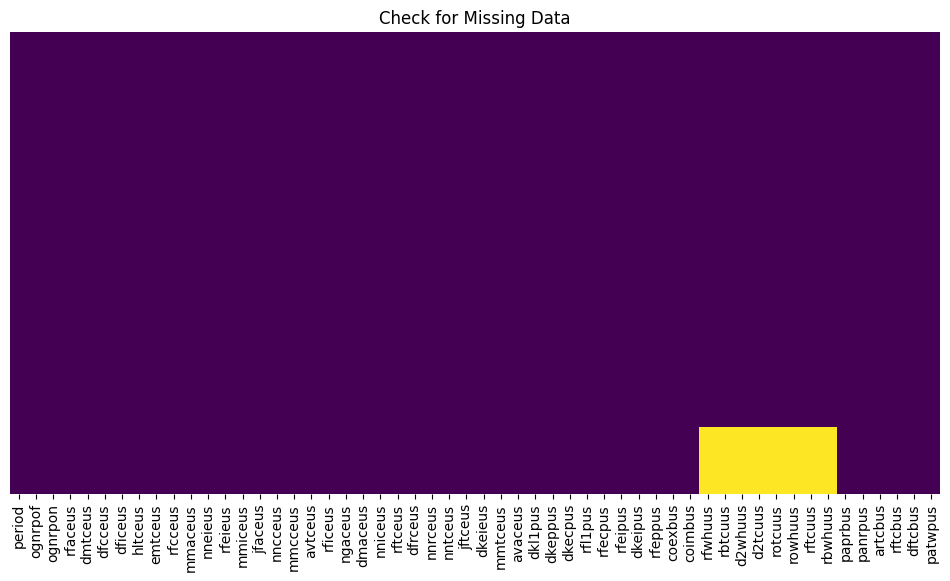

In [20]:
fig = plt.figure(figsize=(12,6))
ax = plt.axes()
ax.set_title('Check for Missing Data')
sns.heatmap(oil_ml_set.df().isnull(),yticklabels=False,cbar=False,cmap='viridis',ax=ax);

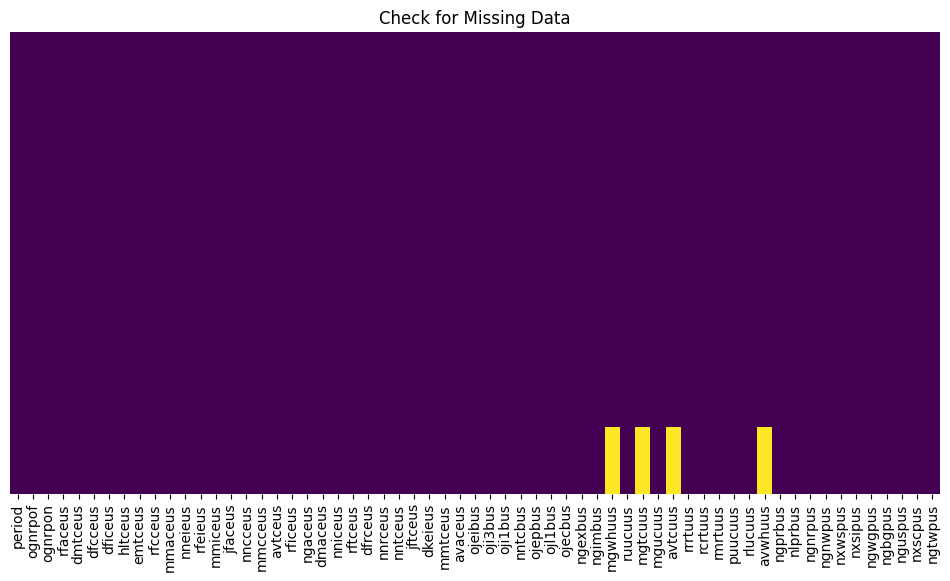

In [21]:
fig = plt.figure(figsize=(12,6))
ax = plt.axes()
ax.set_title('Check for Missing Data')
sns.heatmap(gas_ml_set.df().isnull(),yticklabels=False,cbar=False,cmap='viridis',ax=ax);

Cleaning

In [22]:
def clean_ml_set(
        ml_set : duckdb.DuckDBPyRelation,
        ml_set_cols: list = None
        ):
    print(ml_set.shape)
    ml_set_cleaned = ml_set
    
    if not ml_set_cols:
        ml_set_cols = ml_set_cleaned.columns
    
    for col in ml_set_cols:
        ml_set_cleaned = ml_set_cleaned.filter(f"{col} IS NOT NULL")
        
    print(ml_set_cleaned.shape)
    return ml_set_cleaned

#### Feature Selection for Forecasting Model

In [23]:
print("Cleaning oil training set...")
oil_ml_set_attrs = clean_ml_set(oil_ml_set, oil_ml_set.columns[1:])
oil_ml_set_prd_idx = clean_ml_set(oil_ml_set).df().set_index('period')
oil_ml_set_cleaned = clean_ml_set(oil_ml_set)

print("Cleaning gas training set...")
gas_ml_set_attrs = clean_ml_set(gas_ml_set, gas_ml_set.columns[1:])
gas_ml_set_prd_idx = clean_ml_set(gas_ml_set).df().set_index('period')
gas_ml_set_cleaned = clean_ml_set(gas_ml_set)

Cleaning oil training set...
(312, 54)
(267, 54)
(312, 54)
(267, 54)
(312, 54)
(267, 54)
Cleaning gas training set...
(312, 61)
(267, 61)
(312, 61)
(267, 61)
(312, 61)
(267, 61)


Correlation Check with dependent variable and independent variables

In [24]:
# Check correlation of Oil Rig Count with all other features
oil_rig_count = conn.sql(
    Path("../src/feature_engineering_sql_scripts/oil_features/oil_rigs.sql").read_text()
).fetchone()[0].lower()
with pd.option_context('display.max_rows', None):
    display(oil_ml_set_attrs.df().corr()[oil_rig_count].sort_values(ascending=False))

panrpus    1.000000
patwpus    0.913762
rotcuus    0.797211
rftcuus    0.787686
rowhuus    0.752989
rfwhuus    0.738343
d2whuus    0.718674
rbwhuus    0.650661
emtceus    0.647422
d2tcuus    0.613856
ognrpon    0.534365
period     0.480003
rbtcuus    0.367083
paprbus    0.331197
nneieus    0.329770
nniceus    0.256277
nntceus    0.223956
ngaceus    0.192988
dficeus    0.138040
dmaceus    0.083922
coexbus    0.058616
nncceus    0.049242
mmcceus    0.044884
nnrceus   -0.001023
dftcbus   -0.019591
jfaceus   -0.153749
jftceus   -0.153749
dmtceus   -0.165146
hltceus   -0.176983
dfcceus   -0.221813
dkeipus   -0.280281
dkl1pus   -0.281951
dkeieus   -0.284387
rfaceus   -0.289063
dkeppus   -0.296510
dkecpus   -0.321187
mmaceus   -0.351357
coimbus   -0.357940
artcbus   -0.368888
mmtceus   -0.369681
avaceus   -0.378911
avtceus   -0.378911
dfrceus   -0.404839
ognrpof   -0.432855
mmiceus   -0.439849
rfcceus   -0.535950
rfeipus   -0.563953
rfeieus   -0.563958
rfl1pus   -0.565693
rfeppus   -0.566654


In [25]:
# Check correlation of Gas Rig Count with all other features
gas_rig_count = conn.sql(
    Path("../src/feature_engineering_sql_scripts/gas_features/gas_rigs.sql").read_text()
).fetchone()[0].lower()

with pd.option_context('display.max_rows', None):
    display(gas_ml_set_attrs.df().corr()[gas_rig_count].sort_values(ascending=False))

ngnrpus    1.000000
ngtwpus    0.978904
ngimbus    0.833232
rficeus    0.803921
rfcceus    0.743721
rftceus    0.734295
ognrpof    0.575338
rfaceus    0.571929
ognrpon    0.559720
oji1bus    0.542906
mmaceus    0.536537
avtceus    0.518893
avaceus    0.518893
rfeieus    0.504900
ojepbus    0.503749
avtcuus    0.487571
mmtceus    0.467646
mmiceus    0.459576
dfrceus    0.428426
dmtceus    0.362049
ojeibus    0.355810
ojecbus    0.262760
dfcceus    0.251433
dkeieus    0.224198
jftceus    0.193537
jfaceus    0.193537
oji3bus    0.123310
ojl1bus    0.102344
dficeus    0.096346
mgwhuus    0.015432
dmaceus   -0.005168
nnrceus   -0.027450
ngnwpus   -0.038441
nxscpus   -0.038693
rcrtuus   -0.041070
nxsipus   -0.065200
rmrtuus   -0.070884
ruucuus   -0.071383
mgucuus   -0.080651
nxwspus   -0.094704
nncceus   -0.099550
mgtcuus   -0.114910
hltceus   -0.126282
rrrtuus   -0.132145
ngwgpus   -0.157921
avwhuus   -0.210867
puucuus   -0.223351
nguspus   -0.226892
nntceus   -0.488866
nntcbus   -0.496199


##### **Granger Causality Test**

Granger-Causality Tests assess whether two variables have correlation (move together) but not whether one preditcs the other over time. 

The way it assess if variable X can predict variable Y is if including past values of X improves the prediction of Y - versus using only past values of Y alone. 

We can include the parameter `lag`, where lag takes into account how far-back into the past @ time = i will you consider to predicting the value of Y @ i. So a lag of 5 will take into account X points from i to i - 5.

The procedure goes as such: 

**1. Setup**

Model A: predict Y using only it's own past values

$f(x) = a1*x(t-1) + a2*x(t-2) ... + error_A$

Model B: predict Y using its own past values plus past values of X

$$
f(x) = a1*x(t-1) + a2*x(t-2) ...
            b1*y(t-1) + b2*y(t-2) ...
            + error_B
$$

Both models are fit and coefficient (`a1, a2, b1, b2`...) are fine tuned to minimize overall predicition error across all time points at once

**2. Statistical Results**

Models are compared using the Residual Sum of Squares (RSS) 

```
RSS_A = sum of (actual - predicted)² across all months  ← Model A
RSS_B = sum of (actual - predicted)² across all months  ← Model B
```

The test asks: **is that reducation of error large enough to not be random chance?** Compare the two RSS via chi-squared or F-test on the ratio of the two error totals - and the p-value is able to answer the question.

`p < 0.05` -> Model B is meaningfully better -> X is a useful predictor -> **Keep it**

`p > 0.05` -> Model B is not meaningfully better -> X is not a useful predictor -> **Drop it**
 

In [26]:
def run_granger_causality_tests(
        ml_set : duckdb.DuckDBPyRelation, 
        target_col: str, 
        maxlag: int,
        significance_level : float = 0.05 
        ) -> list:
    """
    Runs granger causality tests for each column against target_col.
    Returns a list of columns that show statistically significant 
    causality at any lag up to maxlag. 
    """
    
    # Get column list from relation - exclude the target column
    col_list = [col 
                for col in ml_set.columns 
                if col != target_col 
                    and col != 'period'
                ]
    
    ml_set = clean_ml_set(ml_set, col_list + [target_col])  # Clean only relevant columns

    ml_df = ml_set.df().set_index('period').resample('MS').mean().sort_index(ascending=False)

    # Drop contstant columns - Granger test requires variance in both series
    constant_cols = [col for col in col_list if ml_df[col].nunique() <= 1]
    if constant_cols:
        print(f"[WARN] Dropping {len(constant_cols)} constant columns: {constant_cols}")
    col_list = [col for col in col_list if col not in constant_cols] # Apply filtering

    significant_cols = [] # For any columns that show significant causality at any lag

    for value in col_list:
        print(f"\n***Test Oil Rig Count Versus {value}***")
        results = grangercausalitytests(
            ml_df[[value, target_col]].dropna(),
            maxlag=maxlag, 
            verbose=True
        )

        # Check if ANY lag is significant - ssr_chi2test p-value
        is_significant = any(
            results[lag][0]['ssr_chi2test'][1] < significance_level
            for lag in results
        )

        if is_significant:
            significant_cols.append(value)
            print(f"[SIGNIFICANT] {value} Granger-causes {target_col}")

    print(f"\n[INFO] {len(significant_cols)}/{len(col_list)} columns significant at p<{significance_level}")
    print(f"[INFO] Significant columns: {significant_cols}")

    return significant_cols

In [27]:
print("Running Granger Causality tests for oil rig count...")
oil_significant_cols = run_granger_causality_tests(oil_ml_set_attrs, target_col=oil_rig_count, maxlag=5)
oil_significant_cols.append(oil_rig_count)
oil_ml_set_attrs = oil_ml_set_attrs.select(", ".join(oil_significant_cols))

print("Running Granger Causality tests for gas rig count...")
gas_significant_cols = run_granger_causality_tests(gas_ml_set_attrs, target_col=gas_rig_count, maxlag=5)
gas_significant_cols.append(gas_rig_count)
gas_ml_set_attrs = gas_ml_set_attrs.select(", ".join(gas_significant_cols))

Running Granger Causality tests for oil rig count...
(267, 54)
(267, 54)

***Test Oil Rig Count Versus ognrpof***

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.4226  , p=0.0654  , df_denom=263, df_num=1
ssr based chi2 test:   chi2=3.4616  , p=0.0628  , df=1
likelihood ratio test: chi2=3.4393  , p=0.0637  , df=1
parameter F test:         F=3.4226  , p=0.0654  , df_denom=263, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.7373  , p=0.0666  , df_denom=260, df_num=2
ssr based chi2 test:   chi2=5.5799  , p=0.0614  , df=2
likelihood ratio test: chi2=5.5219  , p=0.0632  , df=2
parameter F test:         F=2.7373  , p=0.0666  , df_denom=260, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.9045  , p=0.1293  , df_denom=257, df_num=3
ssr based chi2 test:   chi2=5.8693  , p=0.1181  , df=3
likelihood ratio test: chi2=5.8050  , p=0.1215  , df=3
parameter F test:         F=1.9045  , p=0.1293  , df_

##### **Stationarity Test (Augmented Dicky Fuller Test)**

Stationarity Test is meant to indicate whether data is based on randomness or a pattern actually exists. 

`H_0` fail to reject data actually has a trend or a pattern that changes over time (non-stationary)

`H_a` reject the null hypothesis, data does not have a trend or pattern that changes over time (stationary). 

It accomplishes this by looking at two factors, and instead of plotting them (y-axis) against time (x-axis) (this is called **Spurious Regression**), it plots them against each other. By doing so, it removes the day-over-day trends.

For the purposes of curating a ML set, you want data to be stationary. Why data should be kept stationary is because of the concept of **Data Drift**. Because ML models map input ranges to output ranges, data should not inflate (for example, prices of stock over time is worse to make predictions on compared to percentage of stock price over time.)

NOTE: Akaike Information Criterion (AIC) is used to evaluate quality of statstical models given a dataset. It selects for the most parsimonious (best possible balance between high predictive power and simplicity) model; penalizing for complexity while evaluating for model fit, preventing overfitting and underfitting

In [28]:
def adf_test(
        series: str,
        title: str = ''
) -> bool:
    """
    Performs Augmented Dickey-Fuller test to check for stationarity.
    Return True for stationary, 
    False for non-stationary.
    """
    print(f"\nADF Test for {title}")
    result = adfuller(
        series.dropna(),
        autolag='AIC' # Akaike Information Criterion
        )

    labels = ['ADF Statistic', 'p-value', '# Lags Used', '# Observations Used']
    out = pd.Series(result[0:4], index=labels)
    
    for key, val in result[4].items():
        out[f'Critical Value ({key})'] = val

    if result[1] <= 0.05:
            print("Strong evidence against the null hypothesis")
            print("Reject the null hypothesis")
            print("Data has no unit root and is stationary")
            return True
    else:
            print("Weak evidence against the null hypothesis")
            print("Fail to reject the null hypothesis")
            print("Data has a unit root and is non-stationary")
            return False


In [29]:
# NOTE: slight deviation here - will have to work with pandas/ numpy based data types instead 
# of duckdb relations to run the ADF tests

oil_stationary = []
for feature in oil_significant_cols:
    if feature == oil_rig_count:
        oil_stationary.append(feature)  # Keep target variable regardless of stationarity
        continue
    print("Analyzing feature: ", feature)
    oil_stationary.append(feature) if adf_test(oil_ml_set_attrs.select(feature).df(), title=feature) else None

print("===================================")
print(f"Found {len(oil_stationary)} Stationary oil features after differencing \n: {"\n".join(oil_stationary)}")

gas_stationary = []
for feature in gas_significant_cols:
    if feature == gas_rig_count:
        gas_stationary.append(feature)  # Keep target variable regardless of stationarity
        continue
    print("Analyzing feature: ", feature)
    gas_stationary.append(feature) if adf_test(gas_ml_set_attrs.select(feature).df(), title=feature) else None

print("===================================")
print(f"Found {len(gas_stationary)} Stationary gas features after differencing \n: {"\n".join(gas_stationary)}")

Analyzing feature:  ognrpon

ADF Test for ognrpon
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary
Analyzing feature:  rfaceus

ADF Test for rfaceus
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary
Analyzing feature:  dmtceus

ADF Test for dmtceus
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary
Analyzing feature:  dfcceus

ADF Test for dfcceus
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary
Analyzing feature:  hltceus

ADF Test for hltceus
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary
Analyzing feature:  emtceus

ADF Test for emtceus
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-

In [30]:
# Trying differencing
oil_ml_set_df = oil_ml_set_prd_idx[oil_significant_cols].diff(periods=2).dropna()

oil_stationary = []
for feature in oil_significant_cols:
    if feature == oil_rig_count:
        oil_stationary.append(feature)  # Keep target variable regardless of stationarity
        continue
    oil_stationary.append(feature) if adf_test(oil_ml_set_df[feature],title=str(feature)) else None

print("===================================")
print(f"Found {len(oil_stationary)} Stationary oil features after differencing \n: {"\n".join(oil_stationary)}")


ADF Test for ognrpon
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary

ADF Test for rfaceus
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary

ADF Test for dmtceus
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary

ADF Test for dfcceus
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary

ADF Test for hltceus
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary

ADF Test for emtceus
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary

ADF Test for mmaceus
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary

ADF Test for rfeieus
Strong evidence against the null hypothesis
Rej

In [31]:
# Trying differencing
gas_ml_set_df = gas_ml_set_prd_idx[gas_significant_cols].diff(periods=2).dropna()

gas_stationary = []
for feature in gas_significant_cols:
    if feature == gas_rig_count:
        gas_stationary.append(feature)  # Keep target variable regardless of stationarity
        continue
    gas_stationary.append(feature) if adf_test(gas_ml_set_df[feature],title=str(feature)) else None

print("===================================")
print(f"Found {len(gas_stationary)} Stationary gas features after differencing \n: {"\n".join(gas_stationary)}")


ADF Test for ognrpon
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary

ADF Test for rfaceus
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary

ADF Test for dmtceus
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary

ADF Test for dfcceus
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary

ADF Test for hltceus
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary

ADF Test for emtceus
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary

ADF Test for rfcceus
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary

ADF Test for mmaceus
Strong evidence against the null hypothesis
Rej

This shows that differencing at a minimum lag of 1 is required to make attributes stationary.

In [32]:
{
    key: ("TIMESTAMP", True) 
    if key == "period" 
    else ("FLOAT", False)
    for key in oil_ml_set_df.columns
}

{'ognrpon': ('FLOAT', False),
 'rfaceus': ('FLOAT', False),
 'dmtceus': ('FLOAT', False),
 'dfcceus': ('FLOAT', False),
 'hltceus': ('FLOAT', False),
 'emtceus': ('FLOAT', False),
 'mmaceus': ('FLOAT', False),
 'rfeieus': ('FLOAT', False),
 'jfaceus': ('FLOAT', False),
 'mmcceus': ('FLOAT', False),
 'avtceus': ('FLOAT', False),
 'ngaceus': ('FLOAT', False),
 'dmaceus': ('FLOAT', False),
 'nniceus': ('FLOAT', False),
 'rftceus': ('FLOAT', False),
 'dfrceus': ('FLOAT', False),
 'nntceus': ('FLOAT', False),
 'jftceus': ('FLOAT', False),
 'dkeieus': ('FLOAT', False),
 'mmtceus': ('FLOAT', False),
 'avaceus': ('FLOAT', False),
 'dkl1pus': ('FLOAT', False),
 'dkeppus': ('FLOAT', False),
 'dkecpus': ('FLOAT', False),
 'rfl1pus': ('FLOAT', False),
 'rfecpus': ('FLOAT', False),
 'rfeipus': ('FLOAT', False),
 'dkeipus': ('FLOAT', False),
 'rfeppus': ('FLOAT', False),
 'coimbus': ('FLOAT', False),
 'rfwhuus': ('FLOAT', False),
 'rbtcuus': ('FLOAT', False),
 'd2whuus': ('FLOAT', False),
 'd2tcuus'

## Saving the final dataset

In [33]:
dbloader = DBLoader()

In [34]:
export_oil_ml_set = conn.sql(f"""
    WITH filtered_period AS (
        SELECT 
            period
        FROM oil_ml_set_cleaned
    )           

    SELECT
        {", ".join(oil_stationary + ['te.period'])}
    FROM pg.silver.v_total_energy_pivot                 te
    JOIN filtered_period                                 p 
        ON te.period = p.period                     
    ORDER BY te.period DESC
""")

In [35]:
dbloader.write_to_postgres(
    relation=export_oil_ml_set,
    table_name="t_oil_ml_set",
    schema={
            key: ("TIMESTAMP", True) 
            if key == "period" 
            else ("NUMERIC", False)
            for key in export_oil_ml_set.columns
            },
    pg_schema="silver",
    duckdb_conn=conn
)


Schema 'silver' is ready.
[INFO] Created 'silver.t_oil_ml_set' with PKs: ['period']
[INFO] Upserted 267 records into 'silver.t_oil_ml_set' on PK conflict of ['period'].


In [36]:
export_gas_ml_set = conn.sql(f"""
    WITH filtered_period AS (
        SELECT 
            period
        FROM gas_ml_set_cleaned
    )           

    SELECT
        {", ".join(gas_stationary + ['te.period'])}
    FROM pg.silver.v_total_energy_pivot                 te
    JOIN filtered_period                                 p 
        ON te.period = p.period                     
    ORDER BY te.period DESC
""")

In [37]:
dbloader.write_to_postgres(
    relation=export_gas_ml_set,
    table_name="t_gas_ml_set",
    schema={
            key: ("TIMESTAMP", True) 
            if key == "period" 
            else ("NUMERIC", False)
            for key in export_gas_ml_set.columns
            },
    pg_schema="silver",
    duckdb_conn=conn
)


Schema 'silver' is ready.
[INFO] Created 'silver.t_gas_ml_set' with PKs: ['period']
[INFO] Upserted 267 records into 'silver.t_gas_ml_set' on PK conflict of ['period'].
